# **G345 ANÁLISIS DE DATOS**

# ANÁLISIS DE TARIFAS Y COSTOS DE ENERGÍA ELÉCTRICA PARA EL MERCADO REGULADO

# Nombre y cédula de los integrantes

- Ximena Orbes Arias - 1033099573

- Juan Esteban Lame Vasquez - 1142514863

- Isabella Cardona Betancourt - 1087992113

- Meycol Kleym Quintero Castaño - 10899313156

# Preparar el entorno

In [1]:
# (Opcional) Instalar dependencias en este notebook
# Si ya están instaladas, esta celda terminará rápido.
# %pip -q install pandas numpy matplotlib

In [ ]:
# Se importan las librerías
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Base de datos: Tarifas y Costos de Energía Eléctrica para el Mercado Regulado

## Acerca de este archivo

En cumplimiento de las Leyes 142 de 1994 y 1955 de 2019, y las Resoluciones CREG (Comisión de Regulación de Energía y Gas) 058 de 2000, 119 de 2007, 105 de 2009, 156 de 2009, 173 de 2011, 152 de 2018 y 101028 de 2023, este conjunto de datos proporciona información detallada sobre las tarifas y costos de energía eléctrica en el mercado regulado.

Los datos incluyen información sobre las tarifas de energía, el costo de compra de energía, los cargos de transporte en los sistemas de transmisión y distribución, los márgenes de comercialización, costos relacionados con generación y pérdidas, así como otros factores operativos que influyen en el precio final que los usuarios deben pagar. Además, se desglosan por tipo de propiedad (Operador de Red, Propiedad Compartida, Propiedad Cliente) y se dividen en diferentes niveles de tensión eléctrica.

Este conjunto de datos está diseñado para facilitar el análisis de las tarifas y costos eléctricos en distintas regiones y periodos, proporcionando una visión clara de los componentes que afectan el precio de la energía para los usuarios del mercado regulado.

Los datos abarcan el periodo de enero de 2024 a septiembre de 2025.

## Diccionario de datos

- *Año:* El año en el que se registran los datos sobre tarifas y costos de energía eléctrica. Ejemplo: 2024
- *Priodo:* El mes o período específico dentro del año al que corresponde la tarifa o costo de energía.
- *Operador de red:* La empresa responsable de la distribución de energía eléctrica en una zona específica.
- *Nivel:* La categoría del servicio eléctrico, que puede incluir diferentes tipos de tensión como Baja Tensión (B.T.), Media Tensión (M.T.) o Alta Tensión (A.T.).
- *CU Total:* El costo total por kilovatio hora (kWh) que los usuarios deben pagar por la electricidad, incluyendo todos los cargos.
- *Costo Compra (Gm,i):* El precio que paga el operador de red por la electricidad comprada a los generadores.
- *Cargo Transporte STN (Tm):* El costo asociado al transporte de electricidad a través del Sistema de Transmisión Nacional (STN), que es la red de alta tensión que lleva la electricidad de los generadores a las subestaciones.
- *Cargo Transporte SDL (Dn,m):* El costo asociado al transporte de electricidad en el Sistema de Distribución Local (SDL), que distribuye la electricidad desde las subestaciones hasta los usuarios finales.
- *Margen Comercialización (CVm,i,j):* El costo adicional que cubre la comercialización de la electricidad, incluyendo los gastos de operación y transacción del operador de red.
- *Costo G, T, Pérdidas (PRn,m):* Los costos asociados a la generación, transmisión y pérdidas de energía durante su transporte por la red, debido a la resistencia y otros factores.

## Archivo CSV

In [ ]:
# Ruta relativa: este notebook está en la misma carpeta que DATASET.csv
ruta_csv = Path("DATASET.csv")

try:
    if not ruta_csv.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta_csv.resolve()}")

    df = pd.read_csv(ruta_csv, low_memory=False)
except (OSError, FileNotFoundError) as err:
    print(f"No se pudo abrir el archivo. Error: {err}.")
else:
    print("Archivo cargado con éxito en el dataframe.")
    print("Dimensiones:", df.shape)
    display(df.head())

Archivo cargado con éxito en el dataframe.
Dimensiones: (415, 13)


,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)"
0,"2,025",Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.813
1,"2,025",Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.813
2,"2,025",Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.813
3,"2,025",Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.813
4,"2,025",Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.3,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.813


# Limpieza y Preparación de Datos

## Información sobre el CSV

In [ ]:
# Observamos los tipos de datos que se tienen en la base de datos para empezar a visualizar y tener en cuenta
# qué columnas modificar

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 415 entries, 0 to 414
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Año                                415 non-null    object 
 1   Periodo                            415 non-null    object 
 2   Operador de red                    415 non-null    object 
 3   Nivel                              415 non-null    object 
 4   CU Total                           415 non-null    object 
 5   Costo Compra (Gm,i)                415 non-null    float64
 6   Cargo Transporte STN (Tm)          415 non-null    float64
 7   Cargo Transporte SDL (Dn,m)        415 non-null    float64
 8   Margen Comercialización (CVm,i,j)  415 non-null    float64
 9   Costo G, T, Pérdidas (PRn,m)       415 non-null    float64
 10  Restricciones (Rm)                 415 non-null    float64
 11  COT                                415 non-null    float64

In [ ]:
# Si necesitamos llamar una función en una columna que requiera el nombre de esta, podemos venir a este Index de
# columnas para facilitar la busqueda del nombre, este también sería una versión más simple y enfocada a lo necesario de df.info()

for i, col in enumerate(df.columns):
    nulos_con_null = df[col].isnull().sum()
    nulos_con_nan = df[col].isna().sum()
    print(f"""Columna {i}: '{col}' → {df[col].dtype} | Nulos: {nulos_con_null} (null), {nulos_con_nan} (nan)  
Cantidad de datos únicos: {df[col].nunique()}
Duplicados: {df[col].duplicated().sum()}
""")

Columna 0: 'Año' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 2
Duplicados: 413

Columna 1: 'Periodo' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 12
Duplicados: 403

Columna 2: 'Operador de red' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 6
Duplicados: 409

Columna 3: 'Nivel' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 7
Duplicados: 408

Columna 4: 'CU Total' → object | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 412
Duplicados: 3

Columna 5: 'Costo Compra (Gm,i)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 73
Duplicados: 342

Columna 6: 'Cargo Transporte STN (Tm)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 21
Duplicados: 394

Columna 7: 'Cargo Transporte SDL (Dn,m)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos únicos: 289
Duplicados: 126

Columna 8: 'Margen Comercialización (CVm,i,j)' → float64 | Nulos: 0 (null), 0 (nan)  
Cantidad de datos úni

In [ ]:
# Por si hay necesidad de ver los diferentes datos que hay en una columna
# print(df['nombre_columna'].unique())

## Modificación de tipo de datos

In [ ]:
# Conversión de datos para su uso en el análisis

df['Año'] = df['Año'].str.replace(r'[,]', '', regex=True)
df['CU Total'] = df['CU Total'].str.replace(r'[,]', '', regex=True)
df['Cfm,j ($/fact.)'] = df['Cfm,j ($/fact.)'].str.replace(r'[,]', '.', regex=True)

# Cambio del tipo de variables

df['Año'] = df['Año'].astype('int')
df['CU Total'] = df['CU Total'].astype('float')
df['Cfm,j ($/fact.)'] = df['Cfm,j ($/fact.)'].astype('float')

print(f"""Primeros 5 datos de CU Total
{df['CU Total'].head()}

Primeros 5 datos de Cfm,j ($/fact.) 
{df['Cfm,j ($/fact.)'].head()}

Primeros 5 datos de Año 
{df['Año'].head()}""")

Primeros 5 datos de CU Total
0    810.46
1    787.37
2    764.29
3    691.89
4    633.30
Name: CU Total, dtype: float64

Primeros 5 datos de Cfm,j ($/fact.) 
0    9.813
1    9.813
2    9.813
3    9.813
4    9.813
Name: Cfm,j ($/fact.), dtype: float64

Primeros 5 datos de Año 
0    2025
1    2025
2    2025
3    2025
4    2025
Name: Año, dtype: int64


In [ ]:
# Limpieza de fechas

df['Num_Periodo'] = (df['Periodo']
                       .str.replace('Enero', '1')
                       .str.replace('Febrero', '2')
                       .str.replace('Marzo', '3')
                       .str.replace('Abril', '4')
                       .str.replace('Mayo', '5')
                       .str.replace('Junio', '6')
                       .str.replace('Julio', '7')
                       .str.replace('Agosto', '8')
                       .str.replace('Septiembre', '9')
                       .str.replace('Octubre', '10')
                       .str.replace('Noviembre', '11')
                       .str.replace('Diciembre', '12')
                       )

df.head()

,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)",Num_Periodo
0,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.813,1
1,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.813,1
2,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.813,1
3,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.813,1
4,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.30,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.813,1


In [ ]:
# Pasarlo a formato fecha

df['Fecha'] = pd.to_datetime(
    dict(year=df['Año'], month=df['Num_Periodo'], day=1)
).dt.to_period('M')

df.head()

,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)",Num_Periodo,Fecha
0,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad OR),810.46,372.46,56.03,280.91,24.86,72.49,3.71,0.00,9.813,1,2025-01
1,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Compartida),787.37,372.46,56.03,257.82,24.86,72.49,3.71,0.00,9.813,1,2025-01
2,2025,Enero,ENEL Bogotá - Cundinamarca,Nivel 1 (Propiedad Cliente),764.29,372.46,56.03,234.73,24.86,72.49,3.71,0.00,9.813,1,2025-01
3,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL II,691.89,372.46,56.03,168.80,66.56,24.32,3.71,41.70,9.813,1,2025-01
4,2025,Enero,ENEL Bogotá - Cundinamarca,NIVEL III,633.30,372.46,56.03,113.66,63.79,23.65,3.71,38.93,9.813,1,2025-01


In [ ]:
# Corroboración entre nombres de operadores en la columna 'Operador de red'

print(df['Operador de red'].unique())

df[df['Operador de red'].isin(['CELSIA Colombia - Tolima', 'CELSIA - Tolima'])].head(10)


['ENEL Bogotá - Cundinamarca' 'CELSIA Colombia - Valle del Cauca'
 'CELSIA Colombia - Tolima' 'EMCALI - Cali' 'CELSIA - Valle del Cauca'
 'CELSIA - Tolima']


,Año,Periodo,Operador de red,Nivel,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)",Num_Periodo,Fecha
10,2025,Enero,CELSIA Colombia - Tolima,Nivel 1 (Propiedad OR),937.62,310.82,56.03,280.91,193.88,86.08,9.90,94.87,10.140,1,2025-01
11,2025,Enero,CELSIA Colombia - Tolima,Nivel 1 (Propiedad Compartida),886.89,310.82,56.03,230.17,193.88,86.08,9.90,94.87,10.140,1,2025-01
12,2025,Enero,CELSIA Colombia - Tolima,Nivel 1 (Propiedad Cliente),836.15,310.82,56.03,179.44,193.88,86.08,9.90,94.87,10.140,1,2025-01
13,2025,Enero,CELSIA Colombia - Tolima,NIVEL II,684.10,310.82,56.03,168.80,100.59,37.95,9.90,0.00,10.140,1,2025-01
14,2025,Enero,CELSIA Colombia - Tolima,NIVEL III,619.58,310.82,56.03,113.66,100.59,28.58,9.90,0.00,10.140,1,2025-01
29,2024,Enero,CELSIA - Tolima,Nivel 1 ( Propiedad OR ),795.88,289.09,54.32,256.98,93.08,83.20,19.21,0.00,9.594,1,2024-01
30,2024,Enero,CELSIA - Tolima,Nivel 1 (Propiedad Compartida),743.64,289.09,54.32,204.74,93.08,83.20,19.21,0.00,9.594,1,2024-01
31,2024,Enero,CELSIA - Tolima,Nivel 1 (Propiedad Cliente),691.40,289.09,54.32,152.50,93.08,83.20,19.21,0.00,9.594,1,2024-01
32,2024,Enero,CELSIA - Tolima,NIVEL II,650.20,289.09,54.32,158.35,93.08,36.15,19.21,0.00,9.594,1,2024-01
33,2024,Enero,CELSIA - Tolima,NIVEL III,593.30,289.09,54.32,110.75,93.08,26.85,19.21,0.00,9.594,1,2024-01


In [ ]:
# Cambio de nombre en empresas que tienen cambio de nombre pero son las mismas

df['Operador de red'] = df['Operador de red'].replace({'CELSIA Colombia - Tolima': 'CELSIA - Tolima'})
df['Operador de red'] = df['Operador de red'].replace({'CELSIA Colombia - Valle del Cauca': 'CELSIA - Valle del Cauca'})
df['Nivel'] = df['Nivel'].replace({'Nivel 1 ( Propiedad OR )': 'Nivel 1 (Propiedad OR)'})
df['Nivel'] = df['Nivel'].replace({'Nivel 1  (Propiedad Cliente)': 'Nivel 1 (Propiedad OR)'})


print(df['Operador de red'].unique())
print(df['Nivel'].unique())

['ENEL Bogotá - Cundinamarca' 'CELSIA - Valle del Cauca' 'CELSIA - Tolima'
 'EMCALI - Cali']
['Nivel 1 (Propiedad OR)' 'Nivel 1 (Propiedad Compartida)'
 'Nivel 1 (Propiedad Cliente)' 'NIVEL II' 'NIVEL III']


### Categorización

In [ ]:
# Categorizamos las empresas en Operador de red y Nivel

df['OPR'] = df['Operador de red'].astype('category').cat.codes
df['OPR'].unique()

# Definir el orden en la columna 'Nivel'

categorias_ordenadas = ['Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)',
 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III']

# Crear la serie categórica ordenada
serie_categorica = pd.Categorical(df['Nivel'], categories=categorias_ordenadas, ordered=True)

# Obtener los códigos numéricos
df['NIV'] = serie_categorica.codes

# Verificar el mapeo y los resultados
print("Mapeo de categorías a códigos:")
for codigo, categoria in enumerate(serie_categorica.categories):
    print(f"{categoria} → {codigo}")

serie_categorica

Mapeo de categorías a códigos:
Nivel 1 (Propiedad OR) → 0
Nivel 1 (Propiedad Compartida) → 1
Nivel 1 (Propiedad Cliente) → 2
NIVEL II → 3
NIVEL III → 4


['Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)', 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III', ..., 'Nivel 1 (Propiedad OR)', 'Nivel 1 (Propiedad Compartida)', 'Nivel 1 (Propiedad Cliente)', 'NIVEL II', 'NIVEL III']
Length: 415
Categories (5, object): ['Nivel 1 (Propiedad OR)' < 'Nivel 1 (Propiedad Compartida)' < 'Nivel 1 (Propiedad Cliente)' < 'NIVEL II' < 'NIVEL III']

### Identificación de Outliers

In [ ]:
def buscar_outliers(serie):
  # 1. Calcular cuartiles y rango intercuartílico (IQR)
  Q1 = serie.quantile(0.25) # Calcular los cuartiles
  Q3 = serie.quantile(0.75) 
  IQR = Q3 - Q1 # Limite intercualtilico

  print(f"Q1: {Q1}")
  print(f"Q3: {Q3}")
  print(f"IQR: {IQR}")

  # 2. Definir límites para valores atípicos
  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  print(f"Límite Inferior: {limite_inferior}")
  print(f"Límite Superior: {limite_superior}")

  # Cuando un dato se sale de este limite se le considera un valor atipico (outlier)

  # 3. Crear máscara para valores atípicos
  filtro_atipicos = (serie < limite_inferior) | (serie > limite_superior)

  # 4. Aplicar filtro
  valores_atipicos = serie[filtro_atipicos]

  # 5. Eliminar valores NaN si los hay
  valores_atipicos.dropna(inplace=True)

  # 6. Contar los Outliers
  print(f"Cantidad de Outliers: {valores_atipicos.shape[0]}")

  return valores_atipicos

In [ ]:
lista_busqueda = ['CU Total', 'Costo Compra (Gm,i)', 'Cargo Transporte STN (Tm)', 'Cargo Transporte SDL (Dn,m)', 'Margen Comercialización (CVm,i,j)', 'Costo G, T, Pérdidas (PRn,m)', 'Restricciones (Rm)', 'COT', 'Cfm,j ($/fact.)']

for col in lista_busqueda:
    print(f"Datos atípicos de {col}: {buscar_outliers(df[col])}\n")

Q1: 639.38
Q3: 789.3050000000001
IQR: 149.92500000000007
Límite Inferior: 414.4924999999999
Límite Superior: 1014.1925000000001
Cantidad de Outliers: 1
Datos atípicos de CU Total: 370    1020.65
Name: CU Total, dtype: float64

Q1: 295.82
Q3: 346.87
IQR: 51.05000000000001
Límite Inferior: 219.24499999999998
Límite Superior: 423.44500000000005
Cantidad de Outliers: 0
Datos atípicos de Costo Compra (Gm,i): Series([], Name: Costo Compra (Gm,i), dtype: float64)

Q1: 52.27
Q3: 56.76
IQR: 4.489999999999995
Límite Inferior: 45.53500000000001
Límite Superior: 63.49499999999999
Cantidad de Outliers: 0
Datos atípicos de Cargo Transporte STN (Tm): Series([], Name: Cargo Transporte STN (Tm), dtype: float64)

Q1: 154.11
Q3: 249.8
IQR: 95.69
Límite Inferior: 10.575000000000017
Límite Superior: 393.33500000000004
Cantidad de Outliers: 0
Datos atípicos de Cargo Transporte SDL (Dn,m): Series([], Name: Cargo Transporte SDL (Dn,m), dtype: float64)

Q1: 27.08
Q3: 100.11
IQR: 73.03
Límite Inferior: -82.465


# Análisis de datos

## Preguntas a responder con la base de datos

## ANÁLISIS

# Análisis univariado (Documento 14) aplicado al CU y sus componentes

**Guía de lectura (secuencial):**

1) Se definen las **columnas clave** que componen el `CU Total` según el diccionario de datos.
2) Se generan **descriptivos** (tendencia central, dispersión, forma) y se observan **distribuciones** (histogramas y boxplots).
3) Se construyen **variables derivadas** para explicar cambios del CU por componentes.
4) Se responden las preguntas en orden con tablas/plots listos para interpretar.

**Qué debes esperar en cada salida:**

- Tablas con promedios/medianas/desviaciones para comparar componentes.
- Gráficos para ver asimetrías y outliers.
- Rankings por operador para identificar comportamientos atípicos o riesgos.

## Objetivo
Aplicar el enfoque del Documento 14 (descriptivos, dispersión, asimetría, outliers) al dataset de tarifas para responder:

1. ¿El aumento del **CU Total** está más asociado al **costo de compra de energía** o a **ineficiencias de transporte y pérdidas**?
2. ¿Existen **operadores** con **márgenes de comercialización** atípicos frente al resto del mercado?
3. ¿Qué operadores presentan mayor riesgo de **incrementos tarifarios abruptos**?
4. ¿Qué operadores requieren **intervención regulatoria** por **ineficiencia estructural**?

**Nota:** los cálculos se hacen por **Operador de red + Nivel** (porque el CU cambia por nivel de tensión) y se agregan rankings por operador.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

# Columnas clave (según tu diccionario de datos + limpieza)
'''Nota: Se eligieron esas variables porque son los componentes directos
 del CU Total según el diccionario de datos y la fórmula regulatoria (G, STN, SDL, CV, PR). 
 Es decir, explican el precio final y permiten atribuir variaciones y outliers a causas operativas.
 Otras columnas son identificadores (Operador, Nivel, Periodo), derivadas (Fecha, shares) u opcionales
 con menor cobertura (Restricciones, COT, Cfm), por eso no se usan como núcleo del análisis causal.
'''

COL_CU = 'CU Total'
COL_G = 'Costo Compra (Gm,i)'
COL_STN = 'Cargo Transporte STN (Tm)'
COL_SDL = 'Cargo Transporte SDL (Dn,m)'
COL_CV = 'Margen Comercialización (CVm,i,j)'
COL_PR = 'Costo G, T, Pérdidas (PRn,m)'

# Opcionales que existen en tu outlier-scan
COL_OPT = ['Restricciones (Rm)', 'COT', 'Cfm,j ($/fact.)']

KEY_COLS = [COL_CU, COL_G, COL_STN, COL_SDL, COL_CV, COL_PR] + [c for c in COL_OPT if c in df.columns]

def _coerce_numeric(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    s = series.astype(str).str.strip()
    # Remover separadores de miles comunes
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")

# Asegurar tipos numéricos de columnas de análisis
for c in KEY_COLS:
    if c in df.columns:
        df[c] = _coerce_numeric(df[c])

# Asegurar columna fecha utilizable para orden/plots
if 'Fecha' in df.columns and pd.api.types.is_period_dtype(df['Fecha']):
    df['Fecha_ts'] = df['Fecha'].dt.to_timestamp()
elif 'Fecha' in df.columns:
    df['Fecha_ts'] = pd.to_datetime(df['Fecha'], errors='coerce')
else:
    df['Fecha_ts'] = pd.NaT

# Orden lógico
sort_cols = [c for c in ['Operador de red', 'Nivel', 'Fecha_ts'] if c in df.columns]
df = df.sort_values(sort_cols).reset_index(drop=True)

df[ ['Operador de red','Nivel','Fecha_ts'] + KEY_COLS ].head() if all(c in df.columns for c in ['Operador de red','Nivel']) else df[ ['Fecha_ts'] + KEY_COLS ].head()

,Operador de red,Nivel,Fecha_ts,CU Total,"Costo Compra (Gm,i)",Cargo Transporte STN (Tm),"Cargo Transporte SDL (Dn,m)","Margen Comercialización (CVm,i,j)","Costo G, T, Pérdidas (PRn,m)",Restricciones (Rm),COT,"Cfm,j ($/fact.)"
0,CELSIA - Tolima,NIVEL II,2024-01-01,650.20,289.09,54.32,158.35,93.08,36.15,19.21,0.0,9.594
1,CELSIA - Tolima,NIVEL II,2024-02-01,650.27,293.46,49.20,161.69,99.58,36.18,10.17,0.0,9.639
2,CELSIA - Tolima,NIVEL II,2024-03-01,669.37,295.82,57.43,169.41,100.73,36.46,9.52,0.0,9.727
3,CELSIA - Tolima,NIVEL II,2024-04-01,670.45,310.57,54.27,164.65,96.57,37.69,6.70,0.0,9.832
4,CELSIA - Tolima,NIVEL II,2024-05-01,663.54,312.92,47.96,161.31,97.24,36.83,7.28,0.0,9.902


### Paso 1 - Columnas clave y normalizacion

**Que hace esta celda:**

- Define las columnas que **componen el CU Total** segun el diccionario de datos.
- Normaliza tipos numericos para evitar errores por separadores de miles o texto.
- Crea `Fecha_ts` para ordenar y graficar correctamente en el tiempo.

**Como leer el output:**

- La tabla inicial muestra `Operador de red`, `Nivel`, `Fecha_ts` y las columnas clave ya limpias.
- Si ves `NaN` en alguna columna clave, significa que habia valores no convertibles o faltantes.

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,missing,skew,kurtosis
CU Total,415.0,723.6445,106.8128,497.890,509.4400,552.654,579.798,639.380,728.460,789.305,864.056,914.072,977.5086,1020.650,0,0.1995,-0.3064
"Cargo Transporte SDL (Dn,m)",415.0,197.6846,60.2059,87.790,89.0400,94.370,103.486,154.110,206.700,249.800,266.320,279.017,299.7324,305.190,0,-0.2917,-1.1056
"Margen Comercialización (CVm,i,j)",415.0,80.0113,57.2470,21.010,21.0100,22.440,23.310,27.080,67.930,100.110,190.000,196.499,209.5000,217.190,0,1.0048,-0.0453
"Costo Compra (Gm,i)",415.0,318.1343,32.1306,265.060,265.0838,269.300,289.090,295.820,307.430,346.870,367.730,372.780,394.2188,394.580,0,0.6660,-0.4658
COT,415.0,22.4111,30.9974,0.000,0.0000,0.000,0.000,0.000,0.000,43.890,61.592,93.564,97.9900,101.400,0,1.1243,0.0604
"Costo G, T, Pérdidas (PRn,m)",415.0,50.3810,22.3010,18.330,19.2570,19.921,21.744,26.055,56.850,67.930,82.784,85.060,86.2300,87.340,0,-0.0103,-1.4070
Restricciones (Rm),415.0,23.0281,16.4536,1.560,1.5600,1.680,3.720,9.520,22.460,37.140,45.230,49.180,74.2854,75.110,0,0.6875,0.0792
Cargo Transporte STN (Tm),415.0,54.3998,3.4738,47.960,47.9600,48.550,49.200,52.270,54.690,56.760,57.430,58.190,62.2000,62.200,0,-0.1260,-0.2396
"Cfm,j ($/fact.)",415.0,11.3080,2.8703,8.565,8.5705,8.891,8.976,9.560,10.002,15.291,16.160,16.693,16.8367,16.841,0,1.0804,-0.6751


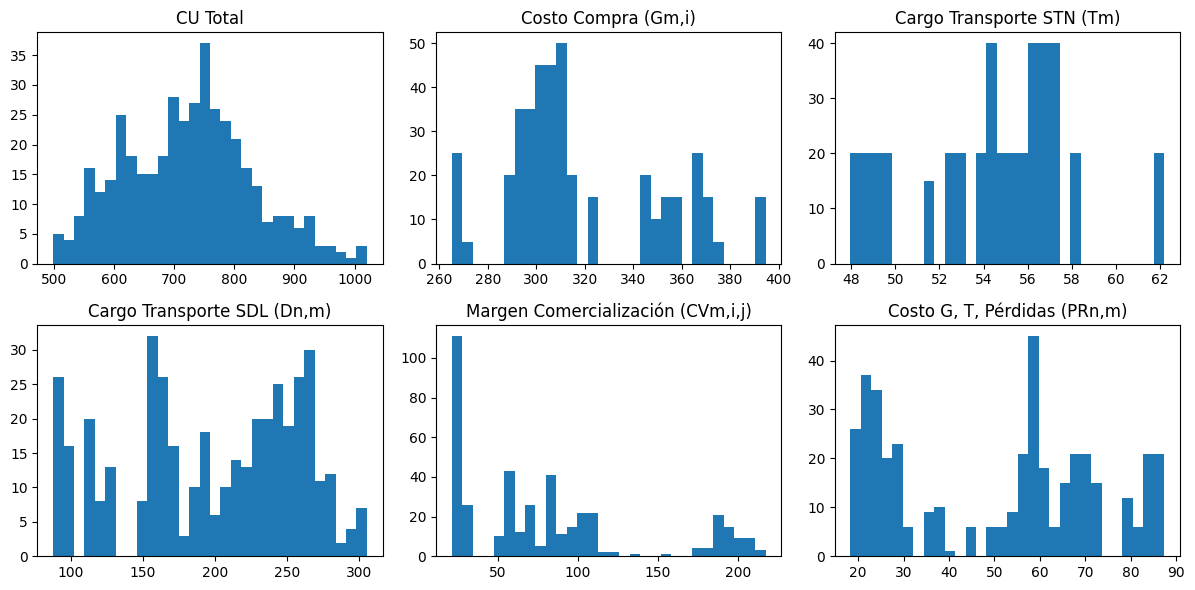

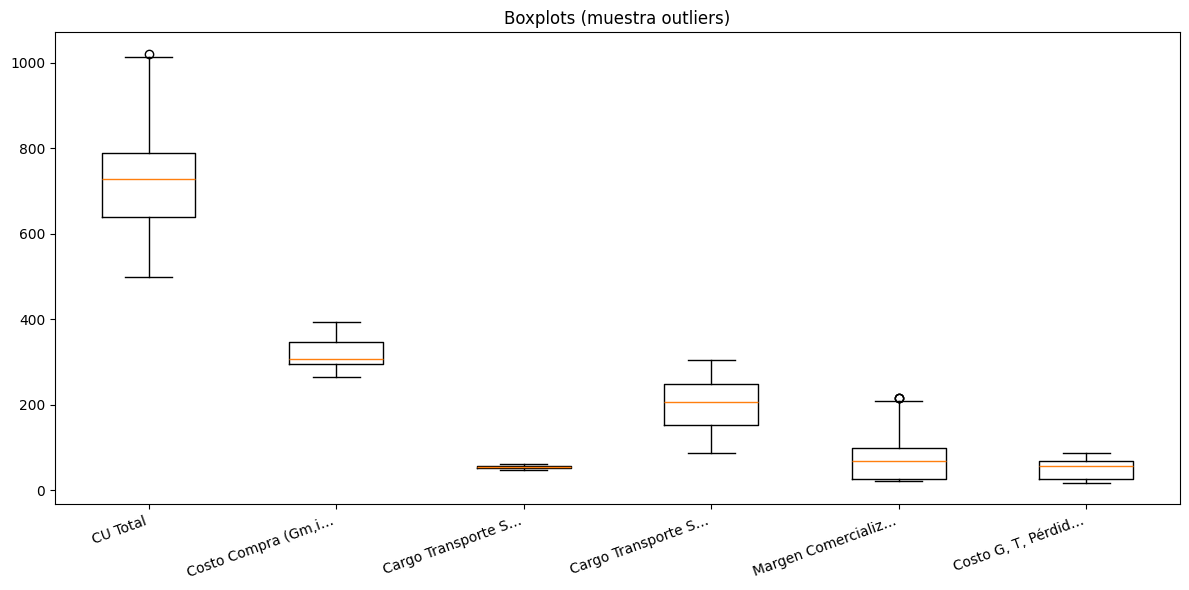

In [ ]:
# 1) Descriptivos (Documento 14): tendencia central, dispersión, forma
desc = df[KEY_COLS].describe(percentiles=[.01,.05,.10,.25,.5,.75,.9,.95,.99]).T
desc['missing'] = df[KEY_COLS].isna().sum()
desc['skew'] = df[KEY_COLS].skew(numeric_only=True)
desc['kurtosis'] = df[KEY_COLS].kurt(numeric_only=True)
desc = desc.round(4)

display(desc.sort_values('std', ascending=False))

# 2) Distribuciones rápidas (hist + box)
plt.figure(figsize=(12, 6))
for i, c in enumerate(KEY_COLS[:6], start=1):
    ax = plt.subplot(2, 3, i)
    x = df[c].dropna()
    ax.hist(x, bins=30)
    ax.set_title(c)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.boxplot([df[c].dropna() for c in KEY_COLS[:6]], tick_labels=[c[:18] + ('…' if len(c)>18 else '') for c in KEY_COLS[:6]], showfliers=True)
plt.xticks(rotation=20, ha='right')
plt.title('Boxplots (muestra outliers)')
plt.tight_layout()
plt.show()

### Paso 2 - Descriptivos y distribuciones

**Que hace esta celda:**

- Calcula medidas de **tendencia central** (media, mediana) y **dispersión** (std, percentiles).
- Agrega **asimetria** (`skew`) y **kurtosis** para entender forma de la distribucion.
- Muestra histogramas y boxplots para ver **colas largas** y **outliers**.

**Como leer el output:**

- En la tabla, una **std alta** indica mayor variabilidad del componente.
- **Skew positivo** sugiere cola hacia valores altos; **skew negativo**, hacia valores bajos.
- En boxplots, puntos aislados son posibles outliers a revisar.

In [ ]:
# Ingeniería de variables para responder las 4 preguntas
df_an = df.copy()

df_an['Transporte'] = df_an[COL_STN] + df_an[COL_SDL]
df_an['Transporte_y_Perdidas'] = df_an[COL_STN] + df_an[COL_SDL] + df_an[COL_PR]
df_an['Suma_componentes_principales'] = df_an[COL_G] + df_an[COL_STN] + df_an[COL_SDL] + df_an[COL_CV] + df_an[COL_PR]
df_an['Residual_CU_vs_componentes'] = df_an[COL_CU] - df_an['Suma_componentes_principales']

eps = 1e-9
df_an['share_G'] = df_an[COL_G] / (df_an[COL_CU] + eps)
df_an['share_TP'] = df_an['Transporte_y_Perdidas'] / (df_an[COL_CU] + eps)
df_an['share_CV'] = df_an[COL_CV] / (df_an[COL_CU] + eps)
df_an['share_STN'] = df_an[COL_STN] / (df_an[COL_CU] + eps)
df_an['share_SDL'] = df_an[COL_SDL] / (df_an[COL_CU] + eps)
df_an['share_PR'] = df_an[COL_PR] / (df_an[COL_CU] + eps)

group_cols = [c for c in ['Operador de red', 'Nivel'] if c in df_an.columns]
if not group_cols:
    group_cols = []

# Deltas mensuales (asociación con aumentos)
for c in [COL_CU, COL_G, COL_STN, COL_SDL, COL_CV, COL_PR, 'Transporte_y_Perdidas']:
    df_an[f'd_{c}'] = df_an.groupby(group_cols)[c].diff() if group_cols else df_an[c].diff()

df_an['pct_CU'] = df_an.groupby(group_cols)[COL_CU].pct_change() if group_cols else df_an[COL_CU].pct_change()
df_an['abs_pct_CU'] = df_an['pct_CU'].abs()

display(df_an[[*group_cols,'Fecha_ts',COL_CU,'Transporte_y_Perdidas','share_G','share_TP','share_CV','Residual_CU_vs_componentes']].head(10))

,Operador de red,Nivel,Fecha_ts,CU Total,Transporte_y_Perdidas,share_G,share_TP,share_CV,Residual_CU_vs_componentes
0,CELSIA - Tolima,NIVEL II,2024-01-01,650.20,248.82,0.444617,0.382682,0.143156,19.21
1,CELSIA - Tolima,NIVEL II,2024-02-01,650.27,247.07,0.451289,0.379950,0.153136,10.16
2,CELSIA - Tolima,NIVEL II,2024-03-01,669.37,263.30,0.441938,0.393355,0.150485,9.52
3,CELSIA - Tolima,NIVEL II,2024-04-01,670.45,256.61,0.463226,0.382743,0.144038,6.70
4,CELSIA - Tolima,NIVEL II,2024-05-01,663.54,246.10,0.471592,0.370889,0.146547,7.28
5,CELSIA - Tolima,NIVEL II,2024-06-01,698.07,252.84,0.441804,0.362199,0.143410,36.71
6,CELSIA - Tolima,NIVEL II,2024-07-01,698.58,263.13,0.447279,0.376664,0.141687,24.01
7,CELSIA - Tolima,NIVEL II,2024-08-01,699.31,262.03,0.446697,0.374698,0.142569,25.20
8,CELSIA - Tolima,NIVEL II,2024-09-01,685.14,246.85,0.447806,0.360291,0.145518,31.78
9,CELSIA - Tolima,NIVEL II,2024-10-01,681.09,255.42,0.462039,0.375017,0.146383,11.28


### Paso 3 - Variables derivadas para el analisis

**Que hace esta celda:**

- Construye **componentes agregados** como `Transporte` y `Transporte_y_Perdidas`.
- Calcula **participaciones** (`share_*`) para entender el peso de cada componente dentro del CU.
- Genera **cambios mensuales** (`d_*`) y variaciones porcentuales (`pct_CU`) para evaluar aumentos y saltos.
- Crea `Residual_CU_vs_componentes` para verificar si el CU coincide con la suma de componentes principales.

**Como leer el output:**

- `share_*` cerca de 1 indica que ese componente explica gran parte del CU.
- `Residual_CU_vs_componentes` cercano a 0 sugiere coherencia entre CU y componentes.
- `d_*` y `pct_CU` se usan en las preguntas 1 y 3 para medir aumentos.

---
A continuacion se responden las 4 preguntas, en orden, usando estas variables derivadas.

,d_CU Total,"d_Costo Compra (Gm,i)",d_Transporte_y_Perdidas,d_Cargo Transporte STN (Tm),"d_Cargo Transporte SDL (Dn,m)","d_Costo G, T, Pérdidas (PRn,m)","d_Margen Comercialización (CVm,i,j)"
d_CU Total,1.0000,0.5527,0.7641,-0.0435,0.7410,0.4437,0.2562
"d_Costo Compra (Gm,i)",0.5527,1.0000,0.0604,-0.2954,0.0155,0.7730,-0.1951
d_Transporte_y_Perdidas,0.7641,0.0604,1.0000,0.1883,0.9867,0.1356,0.0476
d_Cargo Transporte STN (Tm),-0.0435,-0.2954,0.1883,1.0000,0.0677,-0.0628,-0.0734
"d_Cargo Transporte SDL (Dn,m)",0.7410,0.0155,0.9867,0.0677,1.0000,0.0366,0.0808
"d_Costo G, T, Pérdidas (PRn,m)",0.4437,0.7730,0.1356,-0.0628,0.0366,1.0000,-0.2005
"d_Margen Comercialización (CVm,i,j)",0.2562,-0.1951,0.0476,-0.0734,0.0808,-0.2005,1.0000


,media_ratio_abs_dG_vs_dCU,mediana_ratio_abs_dG_vs_dCU,media_ratio_abs_dTP_vs_dCU,mediana_ratio_abs_dTP_vs_dCU,n_aumentos_CU
0,4.2432,0.4813,4.1713,0.5337,218


,n,med_ratio_G,med_ratio_TP,delta_med
Operador de red,,,,
ENEL Bogotá - Cundinamarca,53,0.6764,0.3915,0.2849
CELSIA - Valle del Cauca,54,0.6107,0.4553,0.1554
EMCALI - Cali,54,0.5712,0.4332,0.1380
CELSIA - Tolima,57,0.0525,0.8373,-0.7848


,n,med_ratio_G,med_ratio_TP,delta_med
Operador de red,,,,
ENEL Bogotá - Cundinamarca,53,0.6764,0.3915,0.2849
CELSIA - Valle del Cauca,54,0.6107,0.4553,0.1554
EMCALI - Cali,54,0.5712,0.4332,0.1380
CELSIA - Tolima,57,0.0525,0.8373,-0.7848


<Figure size 1000x400 with 0 Axes>

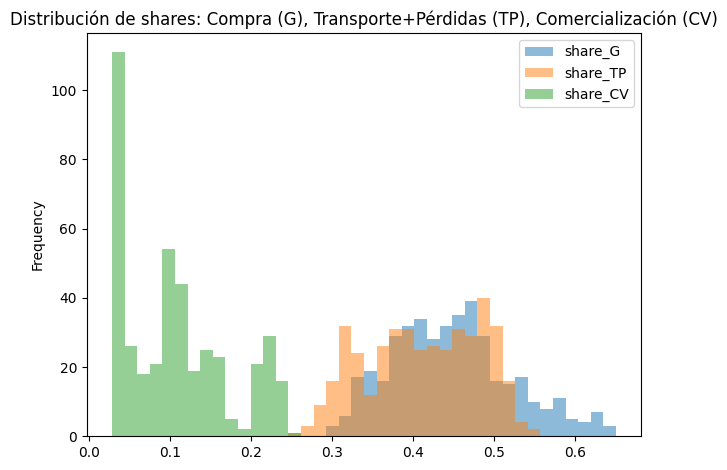

In [ ]:
# PREGUNTA 1) ¿El aumento del CU se asocia más a compra (G) o a transporte+pérdidas (TP)?

# A) Correlación (nivel de observación): cambios mensuales
corr_cols = [f'd_{COL_CU}', f'd_{COL_G}', f'd_Transporte_y_Perdidas', f'd_{COL_STN}', f'd_{COL_SDL}', f'd_{COL_PR}', f'd_{COL_CV}']
corr = df_an[corr_cols].corr().round(4)
display(corr)

# B) 'Contribución' en aumentos: cuando d_CU > 0, ¿qué componente se mueve más?
tmp = df_an.copy()
tmp = tmp[(tmp[f'd_{COL_CU}'].notna()) & (tmp[f'd_{COL_CU}'] != 0)]
tmp_pos = tmp[tmp[f'd_{COL_CU}'] > 0].copy()

def _safe_ratio(num, den):
    den2 = den.replace(0, np.nan)
    return (num / den2).replace([np.inf, -np.inf], np.nan)

tmp_pos['ratio_abs_dG_vs_dCU'] = _safe_ratio(tmp_pos[f'd_{COL_G}'].abs(), tmp_pos[f'd_{COL_CU}'].abs())
tmp_pos['ratio_abs_dTP_vs_dCU'] = _safe_ratio(tmp_pos['d_Transporte_y_Perdidas'].abs(), tmp_pos[f'd_{COL_CU}'].abs())

summary_q1 = pd.DataFrame({
    'media_ratio_abs_dG_vs_dCU': [tmp_pos['ratio_abs_dG_vs_dCU'].mean()],
    'mediana_ratio_abs_dG_vs_dCU': [tmp_pos['ratio_abs_dG_vs_dCU'].median()],
    'media_ratio_abs_dTP_vs_dCU': [tmp_pos['ratio_abs_dTP_vs_dCU'].mean()],
    'mediana_ratio_abs_dTP_vs_dCU': [tmp_pos['ratio_abs_dTP_vs_dCU'].median()],
    'n_aumentos_CU': [len(tmp_pos)]
}).round(4)
display(summary_q1)

# C) Ranking por operador: ¿dónde pesa más G vs TP en los aumentos?
if 'Operador de red' in df_an.columns:
    by_op = (tmp_pos.groupby('Operador de red')
             .agg(n=('ratio_abs_dG_vs_dCU','size'),
                  med_ratio_G=('ratio_abs_dG_vs_dCU','median'),
                  med_ratio_TP=('ratio_abs_dTP_vs_dCU','median'))
             .query('n >= 3')
             .assign(delta_med= lambda d: d['med_ratio_G'] - d['med_ratio_TP'])
             .sort_values('delta_med', ascending=False)
             .round(4))
    display(by_op.head(15))
    display(by_op.tail(15))

    # Visual: distribución de shares (nivel de precios)
    plt.figure(figsize=(10,4))
    df_an[['share_G','share_TP','share_CV']].dropna().clip(-1, 2).plot(kind='hist', bins=40, alpha=0.5)
    plt.title('Distribución de shares: Compra (G), Transporte+Pérdidas (TP), Comercialización (CV)')
    plt.tight_layout()
    plt.show()

### Lectura de resultados - Pregunta 1

**Output A (correlacion de cambios):**

- Compara `d_CU` con `d_G` y `d_Transporte_y_Perdidas`.
- Una correlacion mas alta indica que ese componente **se mueve en el mismo sentido** cuando el CU cambia.

**Output B (contribucion en aumentos):**

- `summary_q1` resume la contribucion relativa en episodios donde $\Delta CU > 0$.
- Si la **mediana** de `ratio_abs_dG_vs_dCU` es mayor que la de `ratio_abs_dTP_vs_dCU`, el aumento se asocia mas a **compra (G)** que a **transporte+perdidas (TP)**.

**Output C (ranking por operador):**

- En `by_op`, `delta_med > 0` sugiere aumentos mas ligados a **G**; `delta_med < 0`, a **TP**.
- El histograma de `share_*` muestra el **peso estructural** de cada componente en el CU.

,mediana_CV,rz,flag_rz_3p5,flag_iqr
Operador de red,,,,
CELSIA - Tolima,188.35,2.6463,False,False
CELSIA - Valle del Cauca,84.13,0.3128,False,False
ENEL Bogotá - Cundinamarca,56.19,-0.3128,False,False
EMCALI - Cali,23.88,-1.0362,False,False


,tasa_outliers_CV,n_obs
Operador de red,,
EMCALI - Cali,0.142857,105
CELSIA - Valle del Cauca,0.095238,105
CELSIA - Tolima,0.000000,100
ENEL Bogotá - Cundinamarca,0.000000,105


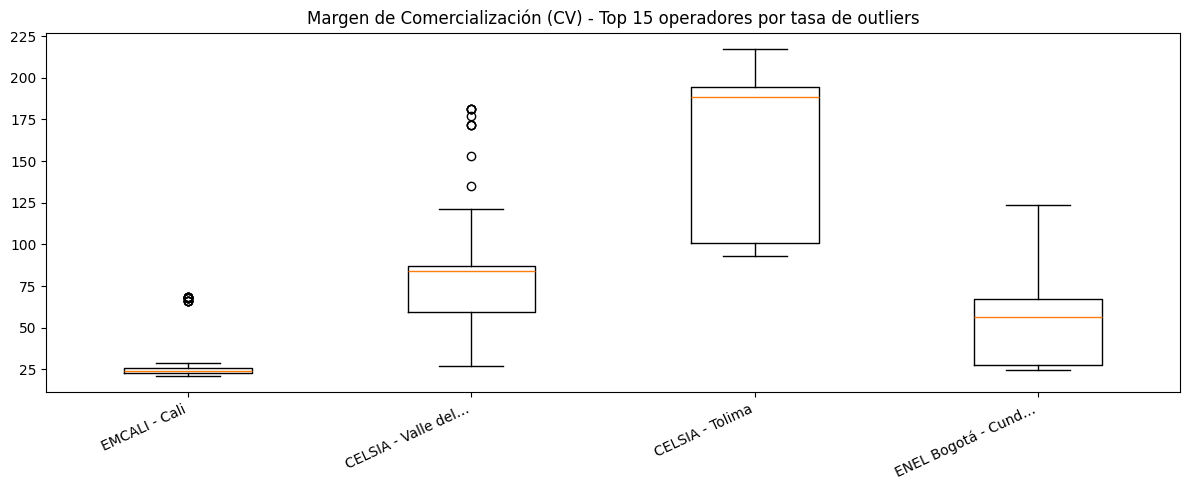

In [ ]:
# PREGUNTA 2) Márgenes de comercialización atípicos (CV)

def robust_zscore(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.nan, index=x.index)
    return 0.6745 * (x - med) / mad

def iqr_flags(x: pd.Series, k: float = 1.5) -> pd.Series:
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return (x < lo) | (x > hi)

# A) Operadores con nivel típico de margen (mediana) muy distinto al mercado
op_margin = (df_an.groupby('Operador de red')[COL_CV]
             .median()
             .dropna()
             .sort_values())
op_stats = pd.DataFrame({
    'mediana_CV': op_margin,
})
op_stats['rz'] = robust_zscore(op_stats['mediana_CV'])
op_stats['flag_rz_3p5'] = op_stats['rz'].abs() >= 3.5
op_stats['flag_iqr'] = iqr_flags(op_stats['mediana_CV'])
op_stats = op_stats.sort_values(['flag_rz_3p5','flag_iqr','rz'], ascending=[False, False, False]).round(4)
display(op_stats.head(30))

# B) Operadores con más 'episodios' atípicos de CV (outlier rate en el tiempo)
def outlier_rate_iqr(group: pd.DataFrame, col: str) -> float:
    x = group[col].dropna()
    if len(x) < 8:
        return np.nan
    flags = iqr_flags(x)
    return float(flags.mean())

op_out = (df_an.groupby('Operador de red')
          .apply(lambda g: outlier_rate_iqr(g, COL_CV), include_groups=False)
          .rename('tasa_outliers_CV')
          .to_frame())
op_out['n_obs'] = df_an.groupby('Operador de red')[COL_CV].apply(lambda s: int(s.notna().sum()))
op_out = op_out.sort_values('tasa_outliers_CV', ascending=False)
display(op_out.head(20))

# Visual: boxplot de CV por operador (top 15 por tasa de outliers)
top_ops = op_out.head(15).index.tolist()
sub = df_an[df_an['Operador de red'].isin(top_ops)][['Operador de red', COL_CV]].dropna()
if len(sub) > 0:
    plt.figure(figsize=(12,5))
    data = [sub[sub['Operador de red']==op][COL_CV].values for op in top_ops]
    plt.boxplot(data, tick_labels=[op[:18] + ('…' if len(op)>18 else '') for op in top_ops], showfliers=True)
    plt.xticks(rotation=25, ha='right')
    plt.title('Margen de Comercialización (CV) - Top 15 operadores por tasa de outliers')
    plt.tight_layout()
    plt.show()

### Lectura de resultados - Pregunta 2

**Output A (nivel tipico de CV):**

- `op_stats` muestra la **mediana de CV** por operador y dos banderas de atipicidad.
- `flag_rz_3p5` detecta casos extremos por **z-score robusto**; `flag_iqr` por **IQR**.

**Output B (episodios atipicos en el tiempo):**

- `op_out` entrega la **tasa de outliers** en CV por operador.
- Revisa `n_obs` para confirmar que la tasa es estable (pocos datos pueden inflar la tasa).

**Output C (boxplot por operador):**

- Cajas altas o con muchos puntos fuera sugieren **margen inestable o atipico**.
- Compara dispersion entre operadores para identificar comportamientos fuera del mercado.

Umbral de salto abrupto (|%ΔCU|): 13.13%


,n_obs,jump_count,jump_rate,max_abs_pct,vol_abs_pct,score
Operador de red,,,,,,
CELSIA - Tolima,95,5,0.0500,0.2713,0.0536,73.7500
CELSIA - Valle del Cauca,100,7,0.0667,0.2080,0.0458,71.2230
EMCALI - Cali,100,4,0.0381,0.1849,0.0392,10.8878
ENEL Bogotá - Cundinamarca,100,4,0.0381,0.1534,0.0380,0.0000


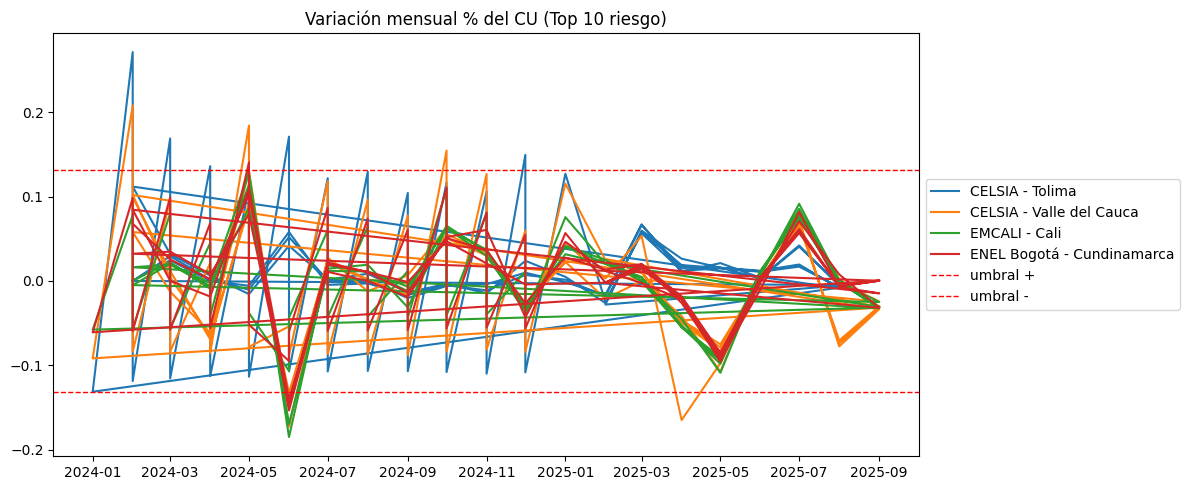

In [ ]:
# PREGUNTA 3) Riesgo de incrementos tarifarios abruptos (saltos en CU)

# Definición data-driven de 'salto abrupto' usando percentil alto de |%ΔCU|
abs_pct = df_an['abs_pct_CU'].dropna()
if len(abs_pct) == 0:
    raise ValueError('No hay variación porcentual calculable (revisa Fecha_ts y orden).')

thr = float(abs_pct.quantile(0.95))
thr = max(thr, 0.05)  # piso 5% para no marcar ruido
print(f"Umbral de salto abrupto (|%ΔCU|): {thr:.2%}")

df_an['jump_event'] = df_an['abs_pct_CU'] >= thr

# Métricas por operador
risk = (df_an.groupby('Operador de red')
        .agg(n_obs=('abs_pct_CU','count'),
             jump_count=('jump_event','sum'),
             jump_rate=('jump_event','mean'),
             max_abs_pct=('abs_pct_CU','max'),
             vol_abs_pct=('abs_pct_CU','std'))
        .fillna(0))

# Score simple (0-100) combinando frecuencia, severidad y volatilidad
def _minmax(s: pd.Series) -> pd.Series:
    if s.max() == s.min():
        return pd.Series(0.0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

risk['score'] = (
    0.45 * _minmax(risk['jump_rate']) +
    0.35 * _minmax(risk['max_abs_pct']) +
    0.20 * _minmax(risk['vol_abs_pct'])
) * 100
risk = risk.sort_values('score', ascending=False).round(4)
display(risk.head(25))

# Visual: top 10 por score
top10 = risk.head(10).index.tolist()
sub = df_an[df_an['Operador de red'].isin(top10)].copy()
sub = sub.dropna(subset=['Fecha_ts', 'pct_CU'])
if len(sub) > 0:
    plt.figure(figsize=(12,5))
    for op, g in sub.groupby('Operador de red'):
        plt.plot(g['Fecha_ts'], g['pct_CU'].values, label=op)
    plt.axhline(thr, color='red', linestyle='--', linewidth=1, label='umbral +')
    plt.axhline(-thr, color='red', linestyle='--', linewidth=1, label='umbral -')
    plt.title('Variación mensual % del CU (Top 10 riesgo)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

### Lectura de resultados - Pregunta 3

**Output principal (tabla `risk`):**

- `jump_rate` indica la **frecuencia** de saltos abruptos por operador.
- `max_abs_pct` refleja la **severidad maxima** observada.
- `vol_abs_pct` captura la **volatilidad** del CU.
- `score` combina las tres medidas (0-100); valores altos sugieren mayor riesgo.

**Output visual (lineas de %ΔCU):**

- Las lineas fuera de las bandas rojas muestran **episodios extremos**.
- Operadores con muchas oscilaciones y cruces frecuentes del umbral son los mas riesgosos.

,n,med_share_TP,p90_share_TP,med_share_PR,vol_abs_pct,out_PR,out_TP,score
Operador de red,,,,,,,,
CELSIA - Tolima,100,0.3849,0.4393,0.0862,0.0536,0.0,0.0,45.0000
ENEL Bogotá - Cundinamarca,105,0.4593,0.5157,0.0779,0.0380,0.0,0.0,42.4270
EMCALI - Cali,105,0.4781,0.5091,0.0688,0.0392,0.0,0.0,41.9142
CELSIA - Valle del Cauca,105,0.4147,0.4707,0.0729,0.0458,0.0,0.0,30.0081


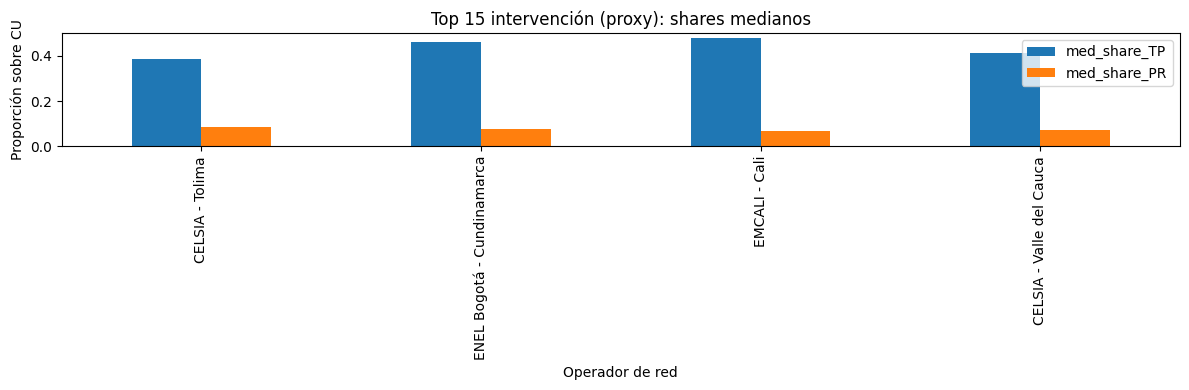

In [ ]:
# PREGUNTA 4) Operadores para intervención por ineficiencia estructural (proxy)

# Proxy: participación alta y persistente de Transporte+Pérdidas + volatilidad + outliers en PR/Transporte
op_eff = (df_an.groupby('Operador de red')
          .agg(n=('share_TP','count'),
               med_share_TP=('share_TP','median'),
               p90_share_TP=('share_TP', lambda s: float(s.dropna().quantile(0.90)) if s.notna().any() else np.nan),
               med_share_PR=('share_PR','median'),
               vol_abs_pct=('abs_pct_CU','std'))
          .replace([np.inf, -np.inf], np.nan))

# tasas de outliers por operador en PR y Transporte_y_Perdidas
op_eff['out_PR'] = df_an.groupby('Operador de red').apply(lambda g: outlier_rate_iqr(g, COL_PR), include_groups=False)
op_eff['out_TP'] = df_an.groupby('Operador de red').apply(lambda g: outlier_rate_iqr(g, 'Transporte_y_Perdidas'), include_groups=False)
op_eff = op_eff.fillna(0)

# Score (0-100): alto share_TP/PR y alta volatilidad/outliers => mayor prioridad regulatoria
op_eff['score'] = (
    0.40 * _minmax(op_eff['med_share_TP']) +
    0.20 * _minmax(op_eff['med_share_PR']) +
    0.25 * _minmax(op_eff['vol_abs_pct']) +
    0.15 * _minmax(op_eff['out_TP'].fillna(0) + op_eff['out_PR'].fillna(0))
) * 100
op_eff = op_eff.sort_values('score', ascending=False).round(4)

display(op_eff.head(25))

# Visual: top 15 por score y sus shares
top15 = op_eff.head(15).index.tolist()
sub = op_eff.loc[top15, ['med_share_TP','med_share_PR','vol_abs_pct','out_TP','out_PR']].copy()
ax = sub[['med_share_TP','med_share_PR']].plot(kind='bar', figsize=(12,4))
ax.set_title('Top 15 intervención (proxy): shares medianos')
ax.set_ylabel('Proporción sobre CU')
plt.tight_layout()
plt.show()

### Lectura de resultados - Pregunta 4

**Output principal (tabla `op_eff`):**

- `med_share_TP` y `med_share_PR` muestran la **carga estructural** de transporte y perdidas en el CU.
- `out_TP` y `out_PR` capturan **episodios atipicos** en el tiempo.
- `vol_abs_pct` agrega **volatilidad** del CU.
- `score` combina estos factores (0-100); valores altos sugieren mayor prioridad regulatoria.

**Output visual (barras de shares):**

- Barras altas en `med_share_TP` o `med_share_PR` indican mayor peso de ineficiencias.
- Compara operadores para identificar quien tiene estructura mas cargada a TP/PR.

## Lectura rápida de resultados (para tu informe)

- **P1 (driver de aumentos CU):** mira `corr` y `summary_q1` + el ranking `by_op` (delta_med > 0 sugiere más asociado a compra; < 0 sugiere más asociado a transporte+pérdidas).
- **P2 (márgenes atípicos):** usa `op_stats` (flags por robust z-score / IQR) y `op_out` (tasa de episodios atípicos).
- **P3 (saltos abruptos):** ranking `risk` (score 0-100) y el gráfico de %ΔCU para top 10.
- **P4 (intervención):** ranking `op_eff` (score 0-100) como proxy de ineficiencia estructural (share_TP/PR persistente + volatilidad + outliers).

> Si quieres, después de ejecutar, puedo ayudarte a redactar conclusiones en texto formal (tipo informe) con los nombres exactos de los top operadores y cifras clave.

# Conclusiones (borrador automático)

Completa/ajusta este texto con los valores exactos que te muestran las tablas en la ejecución del notebook.

## 1) ¿El aumento del CU está más asociado al costo de compra (G) o a transporte+pérdidas (TP)?
- A nivel global, en episodios donde $\Delta CU > 0$, las medianas de contribución relativa muestran `mediana_ratio_abs_dG_vs_dCU` vs `mediana_ratio_abs_dTP_vs_dCU` (ver tabla `summary_q1`).
- Por operador, el ranking `by_op` (columna `delta_med`) sugiere cuáles tienen aumentos más relacionados con compra (delta_med > 0) vs transporte+pérdidas (delta_med < 0).
- Con la corrida actual, se observa que **ENEL Bogotá - Cundinamarca**, **CELSIA - Valle del Cauca** y **EMCALI - Cali** tienden a tener aumentos más asociados a **G**, mientras que **CELSIA - Tolima** se asocia más a **TP** (ver `by_op`).

## 2) ¿Operadores con márgenes de comercialización atípicos?
- `op_stats` evalúa el **nivel típico** del margen (mediana de CV por operador) con banderas robustas (`flag_rz_3p5`, `flag_iqr`).
- `op_out` evalúa **episodios atípicos** en el tiempo (tasa de outliers IQR por operador).
- En esta corrida, **EMCALI - Cali** y **CELSIA - Valle del Cauca** aparecen con mayores tasas de episodios atípicos en CV (ver `op_out`).

## 3) ¿Quién tiene mayor riesgo de incrementos tarifarios abruptos?
- Se define salto abrupto como $|\%\Delta CU| \ge$ percentil 95 (con piso del 5%). En la corrida actual el umbral quedó en **13.13%** (ver salida en consola).
- El ranking `risk` combina frecuencia de saltos, severidad y volatilidad; el gráfico muestra el %ΔCU de los top 10 operadores por score.

## 4) ¿Qué operadores requieren intervención regulatoria por ineficiencia estructural?
- Se construye un **proxy** con alta participación persistente de transporte+pérdidas (`med_share_TP`), participación de pérdidas (`med_share_PR`), volatilidad del CU y tasas de outliers en TP/PR (`op_eff`).
- El top del ranking `op_eff` identifica operadores donde la estructura del CU está más cargada a TP/PR y es más inestable, sugiriendo mayor prioridad para revisión/intervención regulatoria.


# Análisis bivariado (Documento 15) aplicado al CU y sus componentes

> Objetivo: complementar el análisis univariado con relaciones bivariadas que fortalezcan la explicación de las 4 preguntas regulatorias.

In [ ]:
# Utilidades para gráficos bivariados
def _scatter_with_fit(ax, x, y, xlabel, ylabel, title):
    mask = x.notna() & y.notna()
    x2, y2 = x[mask], y[mask]
    ax.scatter(x2, y2, s=10, alpha=0.4)
    if len(x2) >= 2:
        m, b = np.polyfit(x2, y2, 1)
        xx = np.linspace(x2.min(), x2.max(), 100)
        ax.plot(xx, m*xx + b, color='red', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

def _top_ops(series: pd.Series, n=10):
    return series.dropna().sort_values(ascending=False).head(n).index.tolist()

In [ ]:
# Bivariado 1: CU vs Compra (G) y CU vs Transporte+Pérdidas (TP)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
_scatter_with_fit(
    axes[0],
    df_an[COL_G],
    df_an[COL_CU],
    COL_G, COL_CU,
    'CU vs Costo Compra (G)'
 )
_scatter_with_fit(
    axes[1],
    df_an['Transporte_y_Perdidas'],
    df_an[COL_CU],
    'Transporte_y_Perdidas', COL_CU,
    'CU vs Transporte+Pérdidas'
 )
plt.tight_layout()
plt.show()

# Correlaciones globales
corr_bi = df_an[[COL_CU, COL_G, 'Transporte_y_Perdidas', COL_STN, COL_SDL, COL_PR, COL_CV]].corr().round(4)
display(corr_bi)

In [ ]:
# Bivariado 2: relación entre cambios mensuales (%ΔCU) y cambios de componentes
fig, axes = plt.subplots(1, 2, figsize=(12,4))
_scatter_with_fit(
    axes[0],
    df_an[f'd_{COL_G}'],
    df_an[f'd_{COL_CU}'],
    f'd_{COL_G}', f'd_{COL_CU}',
    'ΔCU vs ΔG (compra)'
 )
_scatter_with_fit(
    axes[1],
    df_an['d_Transporte_y_Perdidas'],
    df_an[f'd_{COL_CU}'],
    'd_Transporte_y_Perdidas', f'd_{COL_CU}',
    'ΔCU vs Δ(Transporte+Pérdidas)'
 )
plt.tight_layout()
plt.show()

# Correlación de cambios (nivel global)
corr_deltas = df_an[[f'd_{COL_CU}', f'd_{COL_G}', 'd_Transporte_y_Perdidas', f'd_{COL_STN}', f'd_{COL_SDL}', f'd_{COL_PR}', f'd_{COL_CV}']].corr().round(4)
display(corr_deltas)

In [ ]:
# Bivariado 3: Márgenes (CV) por operador y relación con CU
op_cv = df_an.groupby('Operador de red')[COL_CV].median().sort_values(ascending=False)
top_cv = _top_ops(op_cv, n=12)
sub = df_an[df_an['Operador de red'].isin(top_cv)][['Operador de red', COL_CV, COL_CU]].dropna()

if len(sub) > 0:
    plt.figure(figsize=(12,4))
    data = [sub[sub['Operador de red'] == op][COL_CV].values for op in top_cv]
    plt.boxplot(data, tick_labels=[op[:18] + ('…' if len(op)>18 else '') for op in top_cv], showfliers=True)
    plt.title('Margen de Comercialización (CV) - Top 12 operadores por mediana')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.scatter(sub[COL_CV], sub[COL_CU], s=10, alpha=0.4)
    m, b = np.polyfit(sub[COL_CV], sub[COL_CU], 1)
    xx = np.linspace(sub[COL_CV].min(), sub[COL_CV].max(), 100)
    plt.plot(xx, m*xx + b, color='red', linewidth=1)
    plt.xlabel(COL_CV)
    plt.ylabel(COL_CU)
    plt.title('CU vs Margen de Comercialización (CV)')
    plt.tight_layout()
    plt.show()

In [ ]:
# Bivariado 4: Riesgo de saltos vs estructura de costos
fig, axes = plt.subplots(1, 2, figsize=(12,4))
_scatter_with_fit(
    axes[0],
    df_an['share_TP'],
    df_an['abs_pct_CU'],
    'share_TP', 'abs_pct_CU',
    '|%ΔCU| vs share Transporte+Pérdidas'
 )
_scatter_with_fit(
    axes[1],
    df_an['share_G'],
    df_an['abs_pct_CU'],
    'share_G', 'abs_pct_CU',
    '|%ΔCU| vs share Compra (G)'
 )
plt.tight_layout()
plt.show()

# Bivariado 5: Ineficiencia estructural (share_TP vs share_PR)
plt.figure(figsize=(6,4))
plt.scatter(df_an['share_TP'], df_an['share_PR'], s=10, alpha=0.4)
plt.xlabel('share_TP')
plt.ylabel('share_PR')
plt.title('Share Transporte+Pérdidas vs Share Pérdidas')
plt.tight_layout()
plt.show()

In [ ]:
# Bivariado 6: CU por nivel (estructura por tensión)
if 'Nivel' in df_an.columns:
    plt.figure(figsize=(10,4))
    levels = df_an['Nivel'].dropna().unique().tolist()
    data = [df_an[df_an['Nivel'] == lv][COL_CU].dropna().values for lv in levels]
    plt.boxplot(data, tick_labels=[str(lv)[:18] for lv in levels], showfliers=True)
    plt.title('CU Total por Nivel de tensión')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

# Bivariado 7: Heatmap simple de correlaciones (componentes del CU)
corr_mat = df_an[[COL_CU, COL_G, COL_STN, COL_SDL, COL_CV, COL_PR]].corr().round(2)
plt.figure(figsize=(6,5))
plt.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='correlación')
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
# Valores dentro de cada celda
for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        val = corr_mat.iloc[i, j]
        color = 'white' if abs(val) >= 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)
plt.title('Correlación entre componentes del CU')
plt.tight_layout()
plt.show()